In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from pathlib import Path

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

um.WarningSuppress()

MEANS_DIR = Path("../Data/Models/Monthly_Means")
TS_DIR = Path("../Data/Models/Timeseries")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
#------------------------------------------------------------
# PNAS Figure Specification
#------------------------------------------------------------

PNAS_WIDTH = {1: 3.42, 1.5: 4.5, 2: 7.0}      # inches
PNAS_MAX_HEIGHT = 9.0

def pnas_figsize(cols, height):
    """Figure size in inches for a PNAS column count and chosen height."""
    if height > PNAS_MAX_HEIGHT:
        raise ValueError(f"height {height}in exceeds PNAS maximum of {PNAS_MAX_HEIGHT}in")
    return (PNAS_WIDTH[cols], height)

FS = {              # font sizes
    "panel": 8,     # (a), (b) ... panel letters
    "title": 8,     # panel titles
    "label": 7,     # axis and colorbar labels
    "tick": 6,      # tick labels
    "legend": 6,    # legend
    "annot": 6,     # Axes annotations
}

LW = {              # line widths 
    "spine": 0.8,   # axes spines
    "coast": 0.5,   # map coastlines
    "border": 0.3,  # map borders 
    "grid": 0.2,    # gridlines
    "contour": 0.1, # contours
    "data": 0.8,    # scatter point edgewidths
}

MS = {              # marker sizes
    "proxy": 10,    # scatter points
    "legend": 4,    # legend markers
}

plt.rcParams.update(plt.rcParamsDefault)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [9]:
#------------------------------------------------------------
# Bootstrapping function to return monthly mean and
# 95% C.I. from timeseries
#------------------------------------------------------------

def bootstrap_years_anom(years_old, years_new, n_boot=2000, rng=42):
    rng = np.random.default_rng(rng)
    n_years = years_old.shape[0]
    boot_mon_mean = np.empty((n_boot, 12))
    for i in range(n_boot):
        idx = rng.integers(0, n_years, n_years)
        boot_mon_mean[i] = years_new[idx].mean(dim="year") - years_old[idx].mean(dim="year")

    mon_mean = boot_mon_mean.mean(axis=0)
    ci_upper = np.percentile(boot_mon_mean, 97.5, axis=0)
    ci_lower = np.percentile(boot_mon_mean, 2.5, axis=0)

    return mon_mean, ci_upper, ci_lower

In [ ]:
#------------------------------------------------------------
# Constants
#------------------------------------------------------------

g = 9.80665
R = 6.371e6
SEC_PER_MONTH = 24 * 60**2 * 30

#------------------------------------------------------------
# Bootstrap Precipitation
#------------------------------------------------------------

mhData = um.importUMData(TS_DIR / "MH" / "pr_197001-204912.nc") * SEC_PER_MONTH
piData = um.importUMData(TS_DIR / "PI" / "pr_187001-194912.nc") * SEC_PER_MONTH

GP_mask = umplt.umRegionMask("GP", mhData.longitude, mhData.latitude)
AREA = np.cos(np.deg2rad(mhData.latitude))

gp_mhData = mhData.where(GP_mask).weighted(AREA).mean(dim=["latitude", "longitude"]).coarsen(time=12).construct(time=["year", "month"])
gp_piData = piData.where(GP_mask).weighted(AREA).mean(dim=["latitude", "longitude"]).coarsen(time=12).construct(time=["year", "month"])
pr_mon_mean, pr_ci_upper, pr_ci_lower = bootstrap_years_anom(gp_piData, gp_mhData)

#------------------------------------------------------------
# Bootstrap Meridional Moisture Flux
#------------------------------------------------------------

mh_q = um.importUMData(TS_DIR / "MH" / "q_plev_197001-204912.nc")
pi_q = um.importUMData(TS_DIR / "PI" / "q_plev_187001-194912.nc")

mh_v = um.importUMData(TS_DIR / "MH" / "v_wind_197001-204912.nc")
pi_v = um.importUMData(TS_DIR / "PI" / "v_wind_187001-194912.nc")

p = mh_v.air_pressure
dp_vals = np.abs(np.diff(p.values, prepend=p.values[0])) * 100
dp = xr.DataArray(dp_vals, coords={p.dims[0]: p.values}, dims=p.dims, name="dp")

# GP lower boundary: lat = 33°, lon = -100 to -92°
lat0 = 33.0
lon_min, lon_max = -100.0, -92.0

mh_Fv = (mh_q * mh_v * dp).sel(air_pressure=slice(1000, 700)).sum(dim="air_pressure") / g
pi_Fv = (pi_q * pi_v * dp).sel(air_pressure=slice(1000, 700)).sum(dim="air_pressure") / g

mh_Fv_line = mh_Fv.sel(latitude=lat0, method="nearest").sel(longitude=slice(lon_min + 360, lon_max + 360))
pi_Fv_line = pi_Fv.sel(latitude=lat0, method="nearest").sel(longitude=slice(lon_min + 360, lon_max + 360))

lons = mh_Fv_line.longitude.values
lat_rad = np.deg2rad(float(mh_Fv_line.latitude))

dx = R * np.cos(lat_rad) * np.deg2rad(np.abs(np.gradient(lons)))
dx_da = xr.DataArray(dx, coords={"longitude": lons}, dims=["longitude"])

mh_mFlux = (mh_Fv_line * dx_da).sum(dim="longitude").coarsen(time=12).construct(time=["year", "month"])
pi_mFlux = (pi_Fv_line * dx_da).sum(dim="longitude").coarsen(time=12).construct(time=["year", "month"])
mFlux_mon_mean, mFlux_ci_upper, mFlux_ci_lower = bootstrap_years_anom(pi_mFlux, mh_mFlux)

#------------------------------------------------------------
# Prepare Spatial Means
#------------------------------------------------------------

MH_means = um.importUMData(MEANS_DIR / "MH_monthly_means.nc")
PI_means = um.importUMData(MEANS_DIR / "PI_monthly_means.nc")

p0_anom = (MH_means["surfpress"] - PI_means["surfpress"]) / 100
u_anom = MH_means["u_wind"].sel(p_levs=850) - PI_means["u_wind"].sel(p_levs=850)
v_anom = MH_means["v_wind"].sel(p_levs=850) - PI_means["v_wind"].sel(p_levs=850)

def calc_mFlux_conv(u, v, q, mult=86400):
    p_levs = u.p_levs.values
    dp = np.abs(np.diff(p_levs, prepend=p_levs[0])) * 100

    F_u = (q * u * dp.reshape((1, -1, 1, 1))).sum(dim="p_levs") / g
    F_v = (q * v * dp.reshape((1, -1, 1, 1))).sum(dim="p_levs") / g

    deg2rad = np.deg2rad(1.0)
    coslat = np.cos(np.deg2rad(F_u["lat_p"]))

    dFudx = F_u.differentiate("lon_p") / (R * coslat * deg2rad)
    dFvdy = F_v.differentiate("lat_p") / (R * deg2rad)

    convF = -(dFudx + dFvdy)

    return convF * mult, F_u * mult, F_v * mult

mh_convF, _, _ = calc_mFlux_conv(MH_means["u_wind"], MH_means["v_wind"], MH_means["q_plev"], mult=SEC_PER_MONTH)
pi_convF, _, _ = calc_mFlux_conv(PI_means["u_wind"], PI_means["v_wind"], PI_means["q_plev"], mult=SEC_PER_MONTH)
convF_anom = mh_convF - pi_convF


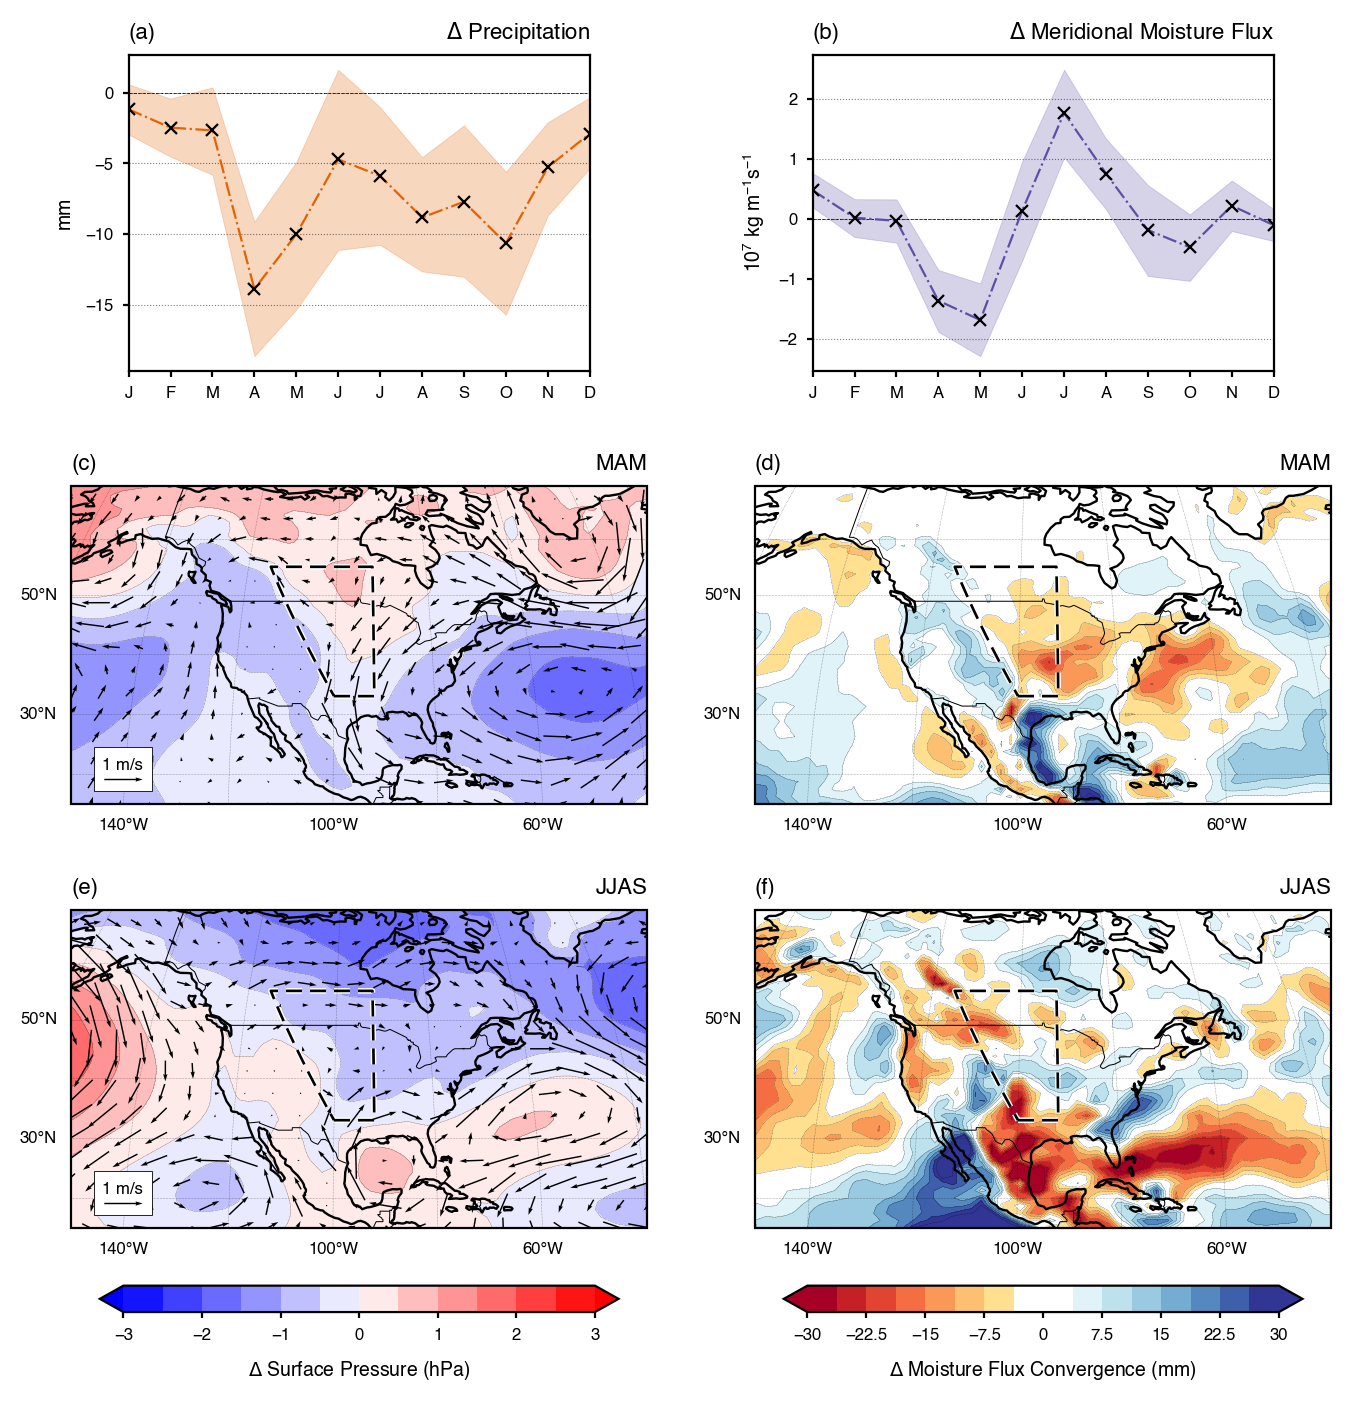

In [ ]:
#------------------------------------------------------------
# Helpers
#------------------------------------------------------------

def white_centre(cmap, levels, n_white=2):
    n = len(levels) - 1
    colors = [cmap(x) for x in np.linspace(0, 1, n)]

    mid = n // 2
    lo = mid - n_white // 2
    for k in range(lo, lo + n_white):
        colors[k] = (1.0, 1.0, 1.0, 1.0)

    cmap_d = ListedColormap(colors)
    cmap_d.set_under(cmap(0.0))
    cmap_d.set_over(cmap(1.0))

    return cmap_d, BoundaryNorm(levels, cmap_d.N)


def cbar_axes_under(fig, axes, width=0.9, height=0.018, pad=0.05):
    fig.canvas.draw()
    boxes = [ax.get_position(original=False) for ax in axes]

    x0 = min(b.x0 for b in boxes)
    x1 = max(b.x1 for b in boxes)
    y0 = min(b.y0 for b in boxes)

    w = (x1 - x0) * width
    return fig.add_axes([0.5 * (x0 + x1) - w / 2, y0 - pad, w, height])

#------------------------------------------------------------
# Figure Properties
#------------------------------------------------------------

fig = plt.figure(figsize=pnas_figsize(2, 6.0), dpi=200)
gs = GridSpec(3, 2, height_ratios=[0.7, 1, 1])

lims, proj = [-150, -40, 15, 70], ccrs.Robinson(central_longitude=-95)
GP_region = umplt.umRegion("GP")

RASTER_Z = 10

#------------------------------------------------------------
# Line Plot Properties
#------------------------------------------------------------

lineplotData = [
    (pr_mon_mean, pr_ci_upper, pr_ci_lower),
    (mFlux_mon_mean * 1e-07, mFlux_ci_upper * 1e-07, mFlux_ci_lower * 1e-07),
]
plot_time = np.arange(12)
colors = ["#E66101", "#5E4FA2"]
titles = [r"$\Delta$ Precipitation", r"$\Delta$ Meridional Moisture Flux"]
units = ["mm", r"$\mathregular{10^{7}}$ kg $\mathregular{m^{-1} s^{-1}}$"]
xticklabs = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
plot_labels = ["a", "b"]

#------------------------------------------------------------
# Line Plots
#------------------------------------------------------------

for i, (mon_mean, ci_upper, ci_lower) in enumerate(lineplotData):
    ax = plt.subplot(gs[0, i])

    ax.plot(plot_time, mon_mean, lw=LW["data"], ls="dashdot", color=colors[i],
            marker="x", ms=MS["legend"], mew=LW["data"], mec="black", zorder=5)
    ax.fill_between(plot_time, ci_upper, ci_lower, alpha=0.25, color=colors[i], lw=LW["border"])

    ax.grid(True, which="major", axis="y", ls="dotted", color="black",
            alpha=0.5, lw=LW["grid"] * 2, zorder=3)

    for ytick, gline in zip(ax.get_yticks(), ax.yaxis.get_gridlines()):
        if np.isclose(ytick, 0.0, atol=1e-8):
            gline.set_visible(False)
            break

    ax.axhline(0, ls="dashed", color="black", alpha=0.9, lw=LW["border"], zorder=4)
    if i == 0:
        ax.axhline(-10, ls="dotted", color="black", alpha=0.5, lw=LW["grid"] * 2, zorder=3)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))

    ax.set_xticks(np.arange(0, 12), labels=xticklabs, fontsize=FS["tick"])
    ax.set_xlim(min(plot_time), max(plot_time))
    if i == 0: ax.set_yticks([0, -5, -10, -15])
    ax.tick_params("both", width=LW["spine"], length=2)
    ax.tick_params(axis="y", labelsize=FS["tick"])

    ax.set_ylabel(units[i], fontsize=FS["label"])
    ax.set_title(titles[i], loc="right", fontsize=FS["title"], pad=6)
    ax.set_title(f"({plot_labels[i]})", loc="left", fontsize=FS["panel"], pad=6)

    ax.spines[["top", "bottom", "right", "left"]].set_linewidth(LW["spine"])

#------------------------------------------------------------
# Map Properties
#------------------------------------------------------------

p0_levs = np.linspace(-3, 3, 13)
mfc_levs = np.linspace(-30, 30, 17)
mfc_cmap, _ = white_centre(cm.RdYlBu, mfc_levs, n_white=2)

map_configs = [
    {
        "anom": p0_anom,
        "lon": p0_anom.longitude,
        "lat": p0_anom.latitude,
        "cmap": cm.bwr,
        "levs": p0_levs,
        "clevs": p0_levs,
        "plot_wind": True,
        "cbar_label": r"$\Delta$ Surface Pressure (hPa)",
        "cbar_ticks": p0_levs[::2],
    },
    {
        "anom": convF_anom,
        "lon": convF_anom.lon_p,
        "lat": convF_anom.lat_p,
        "cmap": mfc_cmap,
        "levs": mfc_levs,
        "clevs": mfc_levs[~np.isclose(mfc_levs, 0.0)],
        "plot_wind": False,
        "cbar_label": r"$\Delta$ Moisture Flux Convergence (mm)",
        "cbar_ticks": mfc_levs[::2],
    },
]

periods = [("MAM", [2, 3, 4]), ("JJAS", [5, 6, 7, 8])]
map_labels = np.array([["c", "d"], ["e", "f"]])

step = 3
U = u_anom[:, ::step, ::step]
V = v_anom[:, ::step, ::step]
X, Y = np.meshgrid(U.lon_p.values, U.lat_p.values)

#------------------------------------------------------------
# Map Plots
#------------------------------------------------------------

col_axes, col_mappables = [], []

for i, cfg in enumerate(map_configs):
    LON, LAT = np.meshgrid(cfg["lon"], cfg["lat"])
    axs = []

    for j, (period, months) in enumerate(periods):
        ax = plt.subplot(gs[j + 1, i], projection=proj)
        ax.set_rasterization_zorder(RASTER_Z)
        axs.append(ax)

        umplt.plotBaseMap(ax, lims, bordercol="black", coastlw=LW["coast"] * 1.7,
                          borderlw=LW["border"] * 1.2, spinelw=LW["spine"])
        gl, glines = umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50],
                                    xlines=[-40, -80, -120, -160], ylines=[20, 40, 60],
                                    labelsize=FS["tick"], lw=LW["grid"], ls="dotted", alph=0.6)
        gl.set_zorder(RASTER_Z + 1)
        glines.set_zorder(RASTER_Z - 1)

        anom = cfg["anom"].isel(time=months).mean(dim="time")

        filled_contour = ax.contourf(LON, LAT, anom, extend="both", cmap=cfg["cmap"],
                                     levels=cfg["levs"], transform=ccrs.PlateCarree(),
                                     transform_first=True, zorder=0)
        ax.contour(LON, LAT, anom, colors="black", levels=cfg["clevs"], linestyles="dashed",
                   linewidths=LW["contour"], transform=ccrs.PlateCarree(),
                   transform_first=True, zorder=1)

        line_kws = {"color": "black", "linestyle": (0, (6, 3)), "linewidth": LW["data"] * 1.2, "zorder": 6,
                    "path_effects": [pe.withStroke(linewidth=LW["data"] * 2.5, foreground="white")]}
        GP_region.plot(ax=ax, line_kws=line_kws, add_coastlines=False, add_label=False)

        if cfg["plot_wind"]:
            U_mean = U.isel(time=months).mean(dim="time").values
            V_mean = V.isel(time=months).mean(dim="time").values
            wind = ax.quiver(X, Y, U_mean, V_mean, pivot="mid", color="black", scale=15,
                             scale_units="width", width=0.0025,
                             transform=ccrs.PlateCarree(), zorder=RASTER_Z + 1)

            # Quiver key for each subplot
            rectangle = Rectangle((0.04, 0.04), 0.1, 0.14, edgecolor="black", facecolor="white",
                                  linewidth=LW["border"], transform=ax.transAxes,
                                  zorder=RASTER_Z + 1)
            ax.add_patch(rectangle)
            ax.quiverkey(wind, 0.09, 0.08, 1, "1 m/s", coordinates="axes",
                         fontproperties={"size": FS["tick"]}, color="k", labelsep=0.03,
                         zorder=RASTER_Z + 1)

        ax.set_title(period, loc="right", fontsize=FS["title"], pad=6, zorder=RASTER_Z + 1)
        ax.set_title(f"({map_labels[j, i]})", loc="left", fontsize=FS["panel"], pad=6,
                     zorder=RASTER_Z + 1)
        ax.spines["geo"].set_zorder(RASTER_Z + 1)

    col_axes.append(axs)
    col_mappables.append(filled_contour)

#------------------------------------------------------------
# Adjust Axes, Colorbars and Save
#------------------------------------------------------------

plt.tight_layout()

axes_to_adjust = [ax for ax in fig.get_axes() if ax.get_title("right") in titles]
for ax in axes_to_adjust:
    umplt.ax_adjust(ax, shrinkx=0.8, shrinky=1.3, shifty=0.05)

for cfg, axs, mappable in zip(map_configs, col_axes, col_mappables):
    cax = cbar_axes_under(fig, axs, width=0.9, height=0.022, pad=0.07)
    cbar = fig.colorbar(mappable, cax=cax, orientation="horizontal", ticks=cfg["cbar_ticks"],
                        format=mticker.StrMethodFormatter("{x:g}"))
    cbar.ax.tick_params(labelsize=FS["tick"], length=2)
    cbar.set_label(cfg["cbar_label"], size=FS["label"], labelpad=6)

plt.show()
